<a href="https://colab.research.google.com/github/anisaratna/indonesian-public-health-nlp/blob/main/Sentimen_Aduan_dan_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas openpyxl numpy
!pip install -q matplotlib seaborn wordcloud
!pip install -q nltk sastrawi
!pip install -q transformers torch scikit-learn

print("Instalasi selesai!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.3 MB/s eta 0:00:00
Instalasi selesai!


In [ ]:
import pandas as pd

df = pd.read_csv('raw data.csv', encoding='latin1')

df.head(5)

,tanggal,teks_aduan,status_penyelesaian,kategori_aduan,sumber_aduan,jangka_waktu
0,1 Januari 2025,"min mau tanya, saya sedang penelitian tentang ...",hijau,Permohonan Informasi,DM INSTAGRAM,1.0
1,3 Januari 2025,"Halo min, untuk informasi terkait magang mahas...",hijau,Magang,DM INSTAGRAM,2.0
2,7 Januari 2025,"Assalamualaikum, Selamat siang Pak/Bu. Mohon m...",hijau,Lowongan kerja,DM INSTAGRAM,0.0
3,10 Januari 2025,min info loker gizi,hijau,Lowongan kerja,DM INSTAGRAM,0.0
4,9 Januari 2025,"Halo kak. Maaf mau tanya, apakah Dinkes Prov J...",hijau,Lowongan kerja,DM INSTAGRAM,1.0


### Eksplorasi

In [ ]:
# Melihat ringkasan informasi DataFrame
print("Informasi umum DataFrame:")
df.info()

Informasi umum DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              181 non-null    object 
 1   teks_aduan           181 non-null    object 
 2   status_penyelesaian  181 non-null    object 
 3   kategori_aduan       181 non-null    object 
 4   sumber_aduan         181 non-null    object 
 5   jangka_waktu         180 non-null    float64
dtypes: float64(1), object(5)
memory usage: 8.7+ KB


In [ ]:
# Mengecek jumlah data yang kosong (missing/null) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isnull().sum())

Jumlah data kosong (missing values) per kolom:
tanggal                1
teks_aduan             1
status_penyelesaian    1
kategori_aduan         1
sumber_aduan           1
jangka_waktu           2
dtype: int64


In [ ]:
# Kita akan bekerja pada kolom 'cleaned_text'
df['cleaned_text'] = df['teks_aduan'].copy()

print("Kolom 'cleaned_text' berhasil dibuat.")
df[['teks_aduan', 'cleaned_text']].head()

Kolom 'cleaned_text' berhasil dibuat.


,teks_aduan,cleaned_text
0,"min mau tanya, saya sedang penelitian tentang ...","min mau tanya, saya sedang penelitian tentang ..."
1,"Halo min, untuk informasi terkait magang mahas...","Halo min, untuk informasi terkait magang mahas..."
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon m...","Assalamualaikum, Selamat siang Pak/Bu. Mohon m..."
3,min info loker gizi,min info loker gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov J...","Halo kak. Maaf mau tanya, apakah Dinkes Prov J..."


### Pra-Pemrosesan Text

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
# Mengubah semua teks di kolom 'cleaned_text' menjadi huruf kecil
df['cleaned_text'] = df['cleaned_text'].str.lower()

print("Case Folding selesai. Semua teks sekarang huruf kecil.")
df[['teks_aduan', 'cleaned_text']].head(10)

Case Folding selesai. Semua teks sekarang huruf kecil.


,teks_aduan,cleaned_text
0,"min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?","min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?"
1,"Halo min, untuk informasi terkait magang mahasiswa di Dinas Kesehatan DKI Jakarta itu bagaimana ya min? Dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? Kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? Di dalam DINKES Prov. Jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?","halo min, untuk informasi terkait magang mahasiswa di dinas kesehatan dki jakarta itu bagaimana ya min? dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? di dalam dinkes prov. jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?"
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon maaf mengganggu waktunya. Mohon izin bertanya, apakah di wilayah kerja Dinas Kesehatan Jawa Tengah membuka lowongan BLUD/BOK untuk lulusan S1 Kesehatan Masyarakat konsentrasi Epidemiologi Pak/Bu?","assalamualaikum, selamat siang pak/bu. mohon maaf mengganggu waktunya. mohon izin bertanya, apakah di wilayah kerja dinas kesehatan jawa tengah membuka lowongan blud/bok untuk lulusan s1 kesehatan masyarakat konsentrasi epidemiologi pak/bu?"
3,min info loker gizi,min info loker gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov Jateng ada pembukaan CPNS 2025 untuk posisi apoteker?","halo kak. maaf mau tanya, apakah dinkes prov jateng ada pembukaan cpns 2025 untuk posisi apoteker?"
5,Selamat siang Bu. Maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?,selamat siang bu. maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?
6,Assalamualaikum. Mohon dicek untuk kualitas bangunan pada saat akreditasi Rumah Sakit. Di Bandarharjo ada rumah sakit yang tembok bangunannya menggunakan Triplek/Multiplek/ bahan yang mudah terbakar. Dan sedang melakukan proses akreditasi naik ke kelas C. Rumah Sakit Dera Asyifa,assalamualaikum. mohon dicek untuk kualitas bangunan pada saat akreditasi rumah sakit. di bandarharjo ada rumah sakit yang tembok bangunannya menggunakan triplek/multiplek/ bahan yang mudah terbakar. dan sedang melakukan proses akreditasi naik ke kelas c. rumah sakit dera asyifa
7,"Kapan ya min ada BLUD di Sukoharjo, Surakarta buka BLUD lo minnn","kapan ya min ada blud di sukoharjo, surakarta buka blud lo minnn"
8,"Selamat pagi,izin bertanya apakah Dinkes Provinsi jawa Tengah menyediakan Training/ Pelatihan Penjamah Pangan (Food Handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami.","selamat pagi,izin bertanya apakah dinkes provinsi jawa tengah menyediakan training/ pelatihan penjamah pangan (food handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami."
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya","dengan hormat,\nkami, pemerintah desa jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin bcg di puskesmas nusawungu ii pada hari sabtu, 25 januari 2025. banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\

In [ ]:
import re

def remove_noise(text):
    # Ensure the input is a string and handle potential NaN values
    text = str(text) if pd.notnull(text) else ''
    # Menghapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Menghapus mention, hashtag, dan karakter non-alfanumerik (kecuali spasi)
    text = re.sub(r'@[^\s]+|#[^\s]+|[^a-zA-Z\s]', '', text)
    # Menghapus angka
    text = re.sub(r'\d+', '', text)
    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Menerapkan fungsi remove_noise ke kolom 'cleaned_text'
df['cleaned_text'] = df['cleaned_text'].apply(remove_noise)

print("Noise Removal selesai. URL, mention, angka, dan tanda baca telah dihapus.")
df[['teks_aduan', 'cleaned_text']].head(10) # Tampilkan 10 baris agar lebih terlihat perubahannya

Noise Removal selesai. URL, mention, angka, dan tanda baca telah dihapus.


,teks_aduan,cleaned_text
0,"min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?",min mau tanya saya sedang penelitian tentang menstruasi dini pada anak apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah
1,"Halo min, untuk informasi terkait magang mahasiswa di Dinas Kesehatan DKI Jakarta itu bagaimana ya min? Dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? Kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? Di dalam DINKES Prov. Jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?",halo min untuk informasi terkait magang mahasiswa di dinas kesehatan dki jakarta itu bagaimana ya min dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu atau harus secara individu di dalam dinkes prov jateng ada bidangconcern apa saja ya min yang tersedia untuk magang
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon maaf mengganggu waktunya. Mohon izin bertanya, apakah di wilayah kerja Dinas Kesehatan Jawa Tengah membuka lowongan BLUD/BOK untuk lulusan S1 Kesehatan Masyarakat konsentrasi Epidemiologi Pak/Bu?",assalamualaikum selamat siang pakbu mohon maaf mengganggu waktunya mohon izin bertanya apakah di wilayah kerja dinas kesehatan jawa tengah membuka lowongan bludbok untuk lulusan s kesehatan masyarakat konsentrasi epidemiologi pakbu
3,min info loker gizi,min info loker gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov Jateng ada pembukaan CPNS 2025 untuk posisi apoteker?",halo kak maaf mau tanya apakah dinkes prov jateng ada pembukaan cpns untuk posisi apoteker
5,Selamat siang Bu. Maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?,selamat siang bu maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada
6,Assalamualaikum. Mohon dicek untuk kualitas bangunan pada saat akreditasi Rumah Sakit. Di Bandarharjo ada rumah sakit yang tembok bangunannya menggunakan Triplek/Multiplek/ bahan yang mudah terbakar. Dan sedang melakukan proses akreditasi naik ke kelas C. Rumah Sakit Dera Asyifa,assalamualaikum mohon dicek untuk kualitas bangunan pada saat akreditasi rumah sakit di bandarharjo ada rumah sakit yang tembok bangunannya menggunakan triplekmultiplek bahan yang mudah terbakar dan sedang melakukan proses akreditasi naik ke kelas c rumah sakit dera asyifa
7,"Kapan ya min ada BLUD di Sukoharjo, Surakarta buka BLUD lo minnn",kapan ya min ada blud di sukoharjo surakarta buka blud lo minnn
8,"Selamat pagi,izin bertanya apakah Dinkes Provinsi jawa Tengah menyediakan Training/ Pelatihan Penjamah Pangan (Food Handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami.",selamat pagiizin bertanya apakah dinkes provinsi jawa tengah menyediakan training pelatihan penjamah pangan food handler kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya",dengan hormat kami pemerintah desa jetis ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin bcg di puskesmas nusawungu ii pada hari sabtu januari banyak warga yang telah mengantre hingga jam namun pulang dengan jawaban stok vaksin habis kami mohon penjelasan mengenai mengapa ketersediaan vaksin bcg langka kapa

In [ ]:
normalization_dict = {
    'min': 'admin', 'kak': 'kakak', 'sist': 'kakak', 'gan': 'kakak',
    'yg': 'yang', 'tdk': 'tidak', 'ga': 'tidak', 'gak': 'tidak',
    'dgn': 'dengan', 'utk': 'untuk', 'tgl': 'tanggal', 'rs': 'rumah sakit',
    'puskesmas': 'pusat kesehatan masyarakat', 'dinkes': 'dinas kesehatan',
    'jateng': 'jawa tengah', 'bpjs': 'bpjs', 'blud': 'blud', 'bok': 'bok',
    'cpns': 'cpns', 'pppk': 'pppk', 'tau':'tahu', 'dn':'dan', 'loker':'lowongan kerja',
    'info':'informasi', 'mhs':'mahasiswa', 'blm':'belum', 'udah':'sudah',
    'trus':'terus', 'jg':'juga', 'tp':'tapi'
}

def normalize_text(text):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

# Menerapkan fungsi normalisasi
df['cleaned_text'] = df['cleaned_text'].apply(normalize_text)

print("Normalization selesai. Kata-kata singkatan telah diubah ke bentuk baku.")
df[['teks_aduan', 'cleaned_text']].head(10)

Normalization selesai. Kata-kata singkatan telah diubah ke bentuk baku.


,teks_aduan,cleaned_text
0,"min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?",admin mau tanya saya sedang penelitian tentang menstruasi dini pada anak apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah
1,"Halo min, untuk informasi terkait magang mahasiswa di Dinas Kesehatan DKI Jakarta itu bagaimana ya min? Dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? Kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? Di dalam DINKES Prov. Jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?",halo admin untuk informasi terkait magang mahasiswa di dinas kesehatan dki jakarta itu bagaimana ya admin dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu atau harus secara individu di dalam dinas kesehatan prov jawa tengah ada bidangconcern apa saja ya admin yang tersedia untuk magang
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon maaf mengganggu waktunya. Mohon izin bertanya, apakah di wilayah kerja Dinas Kesehatan Jawa Tengah membuka lowongan BLUD/BOK untuk lulusan S1 Kesehatan Masyarakat konsentrasi Epidemiologi Pak/Bu?",assalamualaikum selamat siang pakbu mohon maaf mengganggu waktunya mohon izin bertanya apakah di wilayah kerja dinas kesehatan jawa tengah membuka lowongan bludbok untuk lulusan s kesehatan masyarakat konsentrasi epidemiologi pakbu
3,min info loker gizi,admin informasi lowongan kerja gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov Jateng ada pembukaan CPNS 2025 untuk posisi apoteker?",halo kakak maaf mau tanya apakah dinas kesehatan prov jawa tengah ada pembukaan cpns untuk posisi apoteker
5,Selamat siang Bu. Maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?,selamat siang bu maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada
6,Assalamualaikum. Mohon dicek untuk kualitas bangunan pada saat akreditasi Rumah Sakit. Di Bandarharjo ada rumah sakit yang tembok bangunannya menggunakan Triplek/Multiplek/ bahan yang mudah terbakar. Dan sedang melakukan proses akreditasi naik ke kelas C. Rumah Sakit Dera Asyifa,assalamualaikum mohon dicek untuk kualitas bangunan pada saat akreditasi rumah sakit di bandarharjo ada rumah sakit yang tembok bangunannya menggunakan triplekmultiplek bahan yang mudah terbakar dan sedang melakukan proses akreditasi naik ke kelas c rumah sakit dera asyifa
7,"Kapan ya min ada BLUD di Sukoharjo, Surakarta buka BLUD lo minnn",kapan ya admin ada blud di sukoharjo surakarta buka blud lo minnn
8,"Selamat pagi,izin bertanya apakah Dinkes Provinsi jawa Tengah menyediakan Training/ Pelatihan Penjamah Pangan (Food Handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami.",selamat pagiizin bertanya apakah dinas kesehatan provinsi jawa tengah menyediakan training pelatihan penjamah pangan food handler kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya",dengan hormat kami pemerintah desa jetis ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin bcg di pusat kesehatan masyarakat nusawungu ii pada hari sabtu januari banyak warga yang telah mengantre hingga jam namun pulang dengan jawaban stok vaksi

In [ ]:
import nltk
from nltk.corpus import stopwords

# Mengunduh daftar stopwords Bahasa Indonesia dari NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Mendapatkan daftar stopwords
list_stopwords = stopwords.words('indonesian')

# Menambahkan kata-kata umum lain yang sering muncul tapi tidak bermakna di konteks ini
custom_stopwords = [
    # --- Kategori 1: Sapaan, Panggilan, dan Kesopanan ---
    'admin', 'kak', 'kakak', 'min', 'gan', 'sist', 'bapak', 'ibu', 'pak', 'bu',
    'selamat', 'pagi', 'siang', 'sore', 'malam', 'assalamualaikum', 'waalaikumsalam',
    'terima', 'kasih', 'terimakasih', 'mohon', 'maaf', 'izin', 'permisi',
    'hormat', 'bantuannya', 'pencerahannya',

    # --- Kategori 2: Filler Percakapan & Partikel ---
    'ya', 'sih', 'dong', 'kok', 'deh', 'kah', 'lah', 'nya', 'mah', 'loh', 'lo',
    'wow', 'wong', 'lha', 'lur', 'nya'

]

list_stopwords.extend(custom_stopwords)

# Mengubah daftar menjadi set untuk proses yang lebih cepat
stopword_set = set(list_stopwords)

def remove_stopwords(text):
    words = nltk.word_tokenize(text)
    filtered_words = [word for word in words if word not in stopword_set]
    return ' '.join(filtered_words)

# Menerapkan fungsi stopword removal
df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

print("Stopword Removal selesai.")
df[['teks_aduan', 'cleaned_text']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Stopword Removal selesai.


,teks_aduan,cleaned_text
0,"min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?",penelitian menstruasi anak jawa memiliki angka prevalensi menstruasi usia sekolah
1,"Halo min, untuk informasi terkait magang mahasiswa di Dinas Kesehatan DKI Jakarta itu bagaimana ya min? Dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? Kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? Di dalam DINKES Prov. Jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?",halo informasi terkait magang mahasiswa dinas kesehatan dki jakarta dimana informasinya terkait jadwal berkas proposal magangnya diajukan berkelompok individu dinas kesehatan prov jawa bidangconcern tersedia magang
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon maaf mengganggu waktunya. Mohon izin bertanya, apakah di wilayah kerja Dinas Kesehatan Jawa Tengah membuka lowongan BLUD/BOK untuk lulusan S1 Kesehatan Masyarakat konsentrasi Epidemiologi Pak/Bu?",pakbu mengganggu wilayah kerja dinas kesehatan jawa membuka lowongan bludbok lulusan s kesehatan masyarakat konsentrasi epidemiologi pakbu
3,min info loker gizi,informasi lowongan kerja gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov Jateng ada pembukaan CPNS 2025 untuk posisi apoteker?",halo dinas kesehatan prov jawa pembukaan cpns posisi apoteker
5,Selamat siang Bu. Maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?,ketersediaan vaksin booster covid
6,Assalamualaikum. Mohon dicek untuk kualitas bangunan pada saat akreditasi Rumah Sakit. Di Bandarharjo ada rumah sakit yang tembok bangunannya menggunakan Triplek/Multiplek/ bahan yang mudah terbakar. Dan sedang melakukan proses akreditasi naik ke kelas C. Rumah Sakit Dera Asyifa,dicek kualitas bangunan akreditasi rumah sakit bandarharjo rumah sakit tembok bangunannya triplekmultiplek bahan mudah terbakar proses akreditasi kelas c rumah sakit dera asyifa
7,"Kapan ya min ada BLUD di Sukoharjo, Surakarta buka BLUD lo minnn",blud sukoharjo surakarta buka blud minnn
8,"Selamat pagi,izin bertanya apakah Dinkes Provinsi jawa Tengah menyediakan Training/ Pelatihan Penjamah Pangan (Food Handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami.",pagiizin dinas kesehatan provinsi jawa menyediakan training pelatihan penjamah pangan food handler membutuhkan pelatihan kebuutuhan perusahaan
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya",pemerintah desa jetis keluhan warga terkait ketersediaan vaksin bcg pusat kesehatan masyarakat nusawungu ii sabtu januari warga mengantre jam pulang stok vaksin habis penjelasan ketersediaan vaksin bcg langka vaksin bcg tersedia vaksin polindes jarak divaksin bayi cuaca musim penghujan berharap perbaikan pelayanan depannya


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Membuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return stemmer.stem(text)

# Membuat kolom baru untuk hasil stemming
print("Memulai proses Stemming... Ini mungkin memakan waktu beberapa menit.")
df['stemmed_text'] = df['cleaned_text'].apply(stem_text)
print("Stemming selesai.")

# Menampilkan hasil akhir dari pra-pemrosesan
print("\n=== HASIL AKHIR PRA-PEMROSESAN ===")
df[['teks_aduan', 'cleaned_text', 'stemmed_text']].head(10)

Memulai proses Stemming... Ini mungkin memakan waktu beberapa menit.
Stemming selesai.

=== HASIL AKHIR PRA-PEMROSESAN ===


,teks_aduan,cleaned_text,stemmed_text
0,"min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?",penelitian menstruasi anak jawa memiliki angka prevalensi menstruasi usia sekolah,teliti menstruasi anak jawa milik angka prevalensi menstruasi usia sekolah
1,"Halo min, untuk informasi terkait magang mahasiswa di Dinas Kesehatan DKI Jakarta itu bagaimana ya min? Dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? Kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? Di dalam DINKES Prov. Jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?",halo informasi terkait magang mahasiswa dinas kesehatan dki jakarta dimana informasinya terkait jadwal berkas proposal magangnya diajukan berkelompok individu dinas kesehatan prov jawa bidangconcern tersedia magang,halo informasi kait magang mahasiswa dinas sehat dki jakarta mana informasi kait jadwal berkas proposal magang aju kelompok individu dinas sehat prov jawa bidangconcern sedia magang
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon maaf mengganggu waktunya. Mohon izin bertanya, apakah di wilayah kerja Dinas Kesehatan Jawa Tengah membuka lowongan BLUD/BOK untuk lulusan S1 Kesehatan Masyarakat konsentrasi Epidemiologi Pak/Bu?",pakbu mengganggu wilayah kerja dinas kesehatan jawa membuka lowongan bludbok lulusan s kesehatan masyarakat konsentrasi epidemiologi pakbu,pakbu ganggu wilayah kerja dinas sehat jawa buka lowong bludbok lulus s sehat masyarakat konsentrasi epidemiologi pakbu
3,min info loker gizi,informasi lowongan kerja gizi,informasi lowong kerja gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov Jateng ada pembukaan CPNS 2025 untuk posisi apoteker?",halo dinas kesehatan prov jawa pembukaan cpns posisi apoteker,halo dinas sehat prov jawa buka cpns posisi apoteker
5,Selamat siang Bu. Maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?,ketersediaan vaksin booster covid,sedia vaksin booster covid
6,Assalamualaikum. Mohon dicek untuk kualitas bangunan pada saat akreditasi Rumah Sakit. Di Bandarharjo ada rumah sakit yang tembok bangunannya menggunakan Triplek/Multiplek/ bahan yang mudah terbakar. Dan sedang melakukan proses akreditasi naik ke kelas C. Rumah Sakit Dera Asyifa,dicek kualitas bangunan akreditasi rumah sakit bandarharjo rumah sakit tembok bangunannya triplekmultiplek bahan mudah terbakar proses akreditasi kelas c rumah sakit dera asyifa,cek kualitas bangun akreditasi rumah sakit bandarharjo rumah sakit tembok bangun triplekmultiplek bahan mudah bakar proses akreditasi kelas c rumah sakit dera asyifa
7,"Kapan ya min ada BLUD di Sukoharjo, Surakarta buka BLUD lo minnn",blud sukoharjo surakarta buka blud minnn,blud sukoharjo surakarta buka blud minnn
8,"Selamat pagi,izin bertanya apakah Dinkes Provinsi jawa Tengah menyediakan Training/ Pelatihan Penjamah Pangan (Food Handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami.",pagiizin dinas kesehatan provinsi jawa menyediakan training pelatihan penjamah pangan food handler membutuhkan pelatihan kebuutuhan perusahaan,pagiizin dinas sehat provinsi jawa sedia training latih jamah pangan food handler butuh latih kebuutuhan usaha
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya",pemerintah desa jetis keluhan warga terkait ketersediaan vaksin bcg pusat ke

### Analisis Sentimen

In [ ]:
from huggingface_hub import notebook_login
from transformers import pipeline

# Jalankan login lagi untuk memastikan sesi masih aktif
notebook_login()

pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

# Membuat pipeline analisis sentimen
print("\nMembuat pipeline analisis sentimen dengan model baru...")
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model=pretrained_name,
    tokenizer=pretrained_name
)
print("Pipeline siap digunakan.")


Membuat pipeline analisis sentimen dengan model baru...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


Pipeline siap digunakan.


In [ ]:
# Menerapkan pipeline pada kolom 'cleaned_text'
print("Memulai analisis sentimen pada semua data aduan...")

def analyze_sentiment_safely(text):
    try:
        max_length = 512
        truncated_text = text[:max_length]
        return sentiment_analyzer(truncated_text)[0]
    except Exception as e:
        print(f"Error pada teks: {text[:50]}... | Error: {e}")
        return {'label': 'error', 'score': 0.0}

# Menerapkan fungsi dengan aman
sentiment_results = df['cleaned_text'].apply(analyze_sentiment_safely)

print("Analisis sentimen selesai.")

Memulai analisis sentimen pada semua data aduan...
Error pada teks: ... | Error: index 0 is out of bounds for dimension 1 with size 0
Analisis sentimen selesai.


In [ ]:
# Mengekstrak label dan skor dari hasil analisis ke kolom baru
df['sentiment_label'] = sentiment_results.apply(lambda x: x['label'])
df['sentiment_score'] = sentiment_results.apply(lambda x: x['score'])

print("Hasil analisis sentimen telah ditambahkan ke DataFrame.")

# Menampilkan hasil
df[['teks_aduan', 'sentiment_label', 'sentiment_score']].head(10)

Hasil analisis sentimen telah ditambahkan ke DataFrame.


,teks_aduan,sentiment_label,sentiment_score
0,"min mau tanya, saya sedang penelitian tentang menstruasi dini pada anak, apakah jawa tengah memiliki angka prevalensi menstruasi dini usia sekolah?",neutral,0.997730
1,"Halo min, untuk informasi terkait magang mahasiswa di Dinas Kesehatan DKI Jakarta itu bagaimana ya min? Dapat dilihat dimana ya informasinya terkait jadwal dan berkas yang diperlukan? Kemudian untuk proposal magangnya apakah bisa diajukan secara berkelompok begitu, atau harus secara individu? Di dalam DINKES Prov. Jateng ada bidang/concern apa saja ya min yang tersedia untuk magang?",neutral,0.998982
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon maaf mengganggu waktunya. Mohon izin bertanya, apakah di wilayah kerja Dinas Kesehatan Jawa Tengah membuka lowongan BLUD/BOK untuk lulusan S1 Kesehatan Masyarakat konsentrasi Epidemiologi Pak/Bu?",neutral,0.999000
3,min info loker gizi,neutral,0.998213
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov Jateng ada pembukaan CPNS 2025 untuk posisi apoteker?",neutral,0.998925
5,Selamat siang Bu. Maaf mau tanya untuk ketersediaan vaksin booster covid apakah masih ada?,neutral,0.998079
6,Assalamualaikum. Mohon dicek untuk kualitas bangunan pada saat akreditasi Rumah Sakit. Di Bandarharjo ada rumah sakit yang tembok bangunannya menggunakan Triplek/Multiplek/ bahan yang mudah terbakar. Dan sedang melakukan proses akreditasi naik ke kelas C. Rumah Sakit Dera Asyifa,neutral,0.998303
7,"Kapan ya min ada BLUD di Sukoharjo, Surakarta buka BLUD lo minnn",neutral,0.998321
8,"Selamat pagi,izin bertanya apakah Dinkes Provinsi jawa Tengah menyediakan Training/ Pelatihan Penjamah Pangan (Food Handler), kami sedang membutuhkan pelatihan tersebut untuk kebuutuhan perusahaan kami.",neutral,0.998869
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya",neutral,0.999067


In [ ]:
print("Memulai proses koreksi label sentimen...")

# Aturan 1: Jika kategori manualnya adalah pertanyaan, paksa sentimen menjadi 'neutral'
kategori_pertanyaan = ['Permohonan Informasi', 'Magang', 'Lowongan kerja', 'Vaksin Booster Covid']
df.loc[df['kategori_aduan'].isin(kategori_pertanyaan), 'sentiment_label'] = 'neutral'

# Aturan 2: Jika teks mengandung kata kunci negatif yang kuat, paksa sentimen menjadi 'negative'
kata_kunci_negatif = ['pelecehan', 'keluhan', 'jelek', 'lama sekali', 'parah sekali', 'expired', 'kosong']
for kata in kata_kunci_negatif:
    df.loc[df['teks_aduan'].str.contains(kata, case=False, na=False), 'sentiment_label'] = 'negative'

# Aturan 3: Jika teks mengandung kata kunci positif yang kuat, paksa menjadi 'positive'
kata_kunci_positif = ['terima kasih', 'bagus buk', 'terbantu', 'apresiasi']
for kata in kata_kunci_positif:
    df.loc[df['teks_aduan'].str.contains(kata, case=False, na=False), 'sentiment_label'] = 'positive'

print("Koreksi label sentimen selesai.")

# Mari kita lihat hasilnya lagi
print("\nDistribusi sentimen SETELAH dikoreksi:")
print(df['sentiment_label'].value_counts())

Memulai proses koreksi label sentimen...
Koreksi label sentimen selesai.

Distribusi sentimen SETELAH dikoreksi:
sentiment_label
neutral     149
negative     17
positive     15
error         1
Name: count, dtype: int64


Distribusi hasil analisis sentimen:
sentiment_label
neutral     149
negative     17
positive     15
error         1
Name: count, dtype: int64


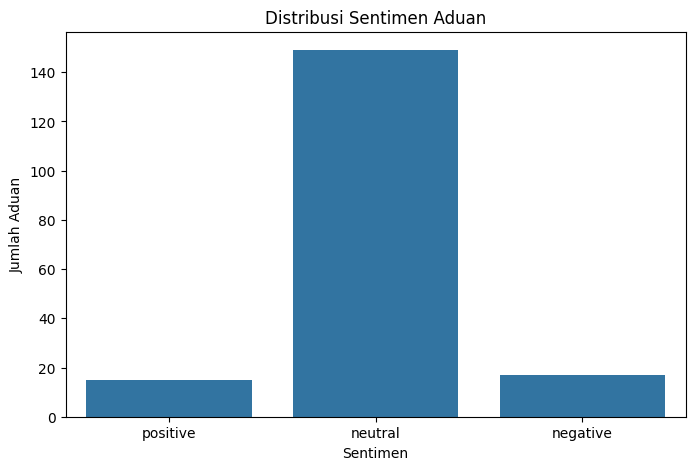

In [ ]:
# Menghitung jumlah masing-masing label sentimen
sentiment_distribution = df['sentiment_label'].value_counts()

print("Distribusi hasil analisis sentimen:")
print(sentiment_distribution)

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_label', data=df, order=['positive', 'neutral', 'negative'])
plt.title('Distribusi Sentimen Aduan')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Aduan')
plt.show()

### Analisis Topik

## sentimen negatif

In [ ]:
# Membuat DataFrame baru yang hanya berisi sentimen negatif
df_negative = df[df['sentiment_label'] == 'negative'].copy()

print(f"Total aduan: {len(df)}")
print(f"Jumlah aduan dengan sentimen negatif: {len(df_negative)}")
print("Berikut adalah contoh aduan negatif:")

# Menampilkan beberapa contoh aduan negatif beserta teks yang sudah di-stem
df_negative[['teks_aduan', 'stemmed_text']].head()

Total aduan: 182
Jumlah aduan dengan sentimen negatif: 17
Berikut adalah contoh aduan negatif:


,teks_aduan,stemmed_text
9,"Dengan hormat,\nKami, Pemerintah Desa Jetis, ingin menyampaikan keluhan dari warga terkait ketersediaan vaksin BCG di Puskesmas Nusawungu II pada hari Sabtu, 25 Januari 2025. Banyak warga yang telah mengantre hingga 3 jam, namun pulang dengan jawaban stok vaksin habis.\nkami mohon penjelasan mengenai :\n1. mengapa ketersediaan vaksin BCG langka?\n2. kapan vaksin BCG akan tersedia kembali?\n3. sebaiknya vaksin diberikan di polindes agar jarak lebih dekat, mengingat yang divaksin adalah bayi dan cuaca sedang dalam musim penghujan.\nKami berharap ada perbaikan dalam pelayanan ke depannya",perintah desa jetis keluh warga kait sedia vaksin bcg pusat sehat masyarakat nusawungu ii sabtu januari warga antre jam pulang stok vaksin habis jelas sedia vaksin bcg langka vaksin bcg sedia vaksin polindes jarak vaksin bayi cuaca musim hujan harap baik layan depan
10,Halo Dinas Kesehatan provinsi Jawa Tengah. Mau tanya vaksin imunisasi Rotavirus Daerah Banjarnegara kosong kak. Kapan ada lagi ya?,halo dinas sehat provinsi jawa vaksin imunisasi rotavirus daerah banjarnegara kosong
17,"pelayanan sangat jelek. lama sekali nunggi sampai 5 jam baru terlayani. para untuk ukuran rumah sakit provinsi. \n1. ada diskriminasi bagi peserta BPJS dan umum khususnya di poli anak\n2. ada jalur fast track yang indikatornya tidak jelas. yang menentukan katanya dari dokternya\n3. tidak ada SOP seberapa lama konsultasi pasien, sehingga banyak antrian yang menunggu dengan alasan pasien konsulnya lama ke dokter\n4. nomo pengaduan yang diinformasikan (direktur, humas) tidak aktif. hanya pajangan saja\n5. pasien lama sekali tidak tahu kapan dan sekitar jam berapa akan mendapat pelayanan, karena sistemnya masih dipanggil manual\n6. pendaftaram/ register online juga ternyata hanya untuk mendapatkan antrian pendaftaran ulang, bukan untuk mendapatkan pelayanan pemeriksaan sehingga tidak berguna karena menjadi 2 kali pendaftaran\nkualitas pelayanan parah sekali. mohon dinas kesehatan provinsi jateng agar mengawasi dan memperhatikan pelayanan RSUD Margono Purwokerto yang ada di bawahnya",layan jelek nunggi jam layan ukur rumah sakit provinsi diskriminasi serta bpjs pol anak jalur fast track indikator tentu dokter sop konsultasi pasien antri tunggu alas pasien konsul dokter nomo adu informasi direktur humas aktif pajang pasien jam layan sistem panggil manual pendaftaram register online antri daftar ulang layan periksa guna kali daftar kualitas layan parah dinas sehat provinsi jawa awas perhati layan rsud margono purwokerto bawah
20,"Selamat siang\nijin bertanya, butuh berapa hari untuk bisa meminta rujukan dari puskesmas ke rumah sakit guna tindak lanjut suatu penyakit? soalnya suami saya sudah 2x ke puskesmas keluhan ada benjolan di leher tetapi cuma dikasih obat. itu pun obat yang pertama kali periksa tidak ada reaksinya untuk benjolannya. malah semakin besar. periksa pertama tanggal 5 Februari 2025. Periksa kedua hari ini tanggal 14 Februari 2025",ijin butuh rujuk pusat sehat masyarakat rumah sakit tindak sakit suami x pusat sehat masyarakat keluh benjol leher kasih obat obat kali periksa reaksi benjol periksa tanggal februari periksa tanggal februari
24,Ini istri saya baru periksa kehamilan dipuskesmas klikiran trus baru sadar dpt Vit C mau expired,istri periksa hamil puskesmas klikiran sadar dpt vit c expired


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Mengambil semua teks negatif yang sudah di-stem
documents = df_negative['stemmed_text'].dropna().tolist()

# Membuat objek TfidfVectorizer
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

# Menerapkan TF-IDF
tfidf_matrix = tfidf.fit_transform(documents)

# Mendapatkan daftar semua kata/frasa (fitur) yang telah dipelajari oleh TF-IDF
feature_names = tfidf.get_feature_names_out()

# Mendapatkan skor TF-IDF untuk setiap kata/frasa
scores = tfidf_matrix.sum(axis=0).A1

# Membuat DataFrame dari kata/frasa dan skornya
topic_df = pd.DataFrame({'topic': feature_names, 'score': scores})

# Mengurutkan DataFrame untuk melihat topik dengan skor tertinggi
top_topics = topic_df.sort_values(by='score', ascending=False).reset_index(drop=True)

print("Top 20 Topik/Kata Kunci Utama dalam Aduan Negatif:")
print(top_topics.head(20))

Top 20 Topik/Kata Kunci Utama dalam Aduan Negatif:
                topic     score
0              upload  0.671394
1               masuk  0.664159
2               ulang  0.647860
3                  gk  0.577350
4              batang  0.577350
5           batang gk  0.577350
6                bpjs  0.533208
7                 udh  0.499640
8         ulang tahun  0.459137
9         tahun kejar  0.459137
10              kejar  0.459137
11              tahun  0.459137
12                sya  0.388607
13          berentiin  0.385081
14  kualifikasi susah  0.385081
15              susah  0.385081
16        kualifikasi  0.385081
17               link  0.385081
18   link kualifikasi  0.385081
19               ijin  0.385081


In [ ]:
# Menghitung kategori manual yang paling sering muncul dalam aduan negatif
top_negative_categories = df_negative['kategori_aduan'].value_counts()

print("Peringkat Kategori Aduan yang Paling Sering Mendapat Sentimen Negatif:")
print(top_negative_categories.head(10))

top_category_name = top_negative_categories.index[0]
print(f"\nContoh teks aduan negatif untuk kategori '{top_category_name}':")

# Menampilkan 5 contoh aduan mentah dari kategori tersebut
pd.set_option('display.max_colwidth', None)
print(df_negative[df_negative['kategori_aduan'] == top_category_name]['teks_aduan'].head())
pd.reset_option('display.max_colwidth')

Peringkat Kategori Aduan yang Paling Sering Mendapat Sentimen Negatif:
kategori_aduan
Lowongan kerja                 3
CKG                            2
SPELING                        2
kepegawaian                    1
Kepesertaan BPJS               1
Aduan Pelayanan Puskesmas      1
Aduan Pelayanan Rumah Sakit    1
Vaksin Booster Covid           1
Pelayanan Perizinan Dinkes     1
Name: count, dtype: int64

Contoh teks aduan negatif untuk kategori 'Lowongan kerja':
115    Mohon maaf web nya kok ga bisa ya. Apa lagi eror atau lagi sibuk sistem nya ya..
116                           Kalau salah upload berkas bisa di upload ulang enggk ya ?
120                                                        Link kualifikasi susah masuk
Name: teks_aduan, dtype: object


### Analisis Data Sentimen Netral

In [ ]:
# Membuat DataFrame baru yang hanya berisi sentimen netral
df_neutral = df[df['sentiment_label'] == 'neutral'].copy()

print(f"Jumlah aduan dengan sentimen netral (pertanyaan): {len(df_neutral)}")
df_neutral[['teks_aduan', 'stemmed_text']].head()

Jumlah aduan dengan sentimen netral (pertanyaan): 162


,teks_aduan,stemmed_text
0,"min mau tanya, saya sedang penelitian tentang ...",teliti menstruasi anak jawa milik angka preval...
1,"Halo min, untuk informasi terkait magang mahas...",halo informasi kait magang mahasiswa dinas seh...
2,"Assalamualaikum, Selamat siang Pak/Bu. Mohon m...",pakbu ganggu wilayah kerja dinas sehat jawa bu...
3,min info loker gizi,informasi lowong kerja gizi
4,"Halo kak. Maaf mau tanya, apakah Dinkes Prov J...",halo dinas sehat prov jawa buka cpns posisi ap...


In [ ]:
# Mengambil semua teks netral yang sudah di-stem
neutral_documents = df_neutral['stemmed_text'].dropna().tolist()

tfidf_neutral = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

# Menerapkan TF-IDF
tfidf_matrix_neutral = tfidf_neutral.fit_transform(neutral_documents)

# Mendapatkan nama fitur/topik
feature_names_neutral = tfidf_neutral.get_feature_names_out()

# Mendapatkan skor
scores_neutral = tfidf_matrix_neutral.sum(axis=0).A1

# Membuat DataFrame
topic_df_neutral = pd.DataFrame({'topic': feature_names_neutral, 'score': scores_neutral})

# Mengurutkan untuk melihat topik pertanyaan teratas
top_neutral_topics = topic_df_neutral.sort_values(by='score', ascending=False).reset_index(drop=True)

print("Top 20 Topik/Kata Kunci Utama dalam Pertanyaan (Sentimen Netral):")
print(top_neutral_topics.head(20))

Top 20 Topik/Kata Kunci Utama dalam Pertanyaan (Sentimen Netral):
            topic     score
0           sehat  7.918201
1            jawa  5.941186
2     dinas sehat  5.578037
3           dinas  5.544091
4           kerja  5.183414
5          lowong  4.921158
6          vaksin  4.736713
7       informasi  4.254143
8    lowong kerja  4.169013
9           sedia  3.794686
10           kait  3.696205
11          sakit  3.642875
12         magang  3.452656
13       provinsi  3.401906
14           umum  3.306728
15         daftar  3.273045
16          rumah  3.254730
17    rumah sakit  3.159931
18           halo  3.154621
19  provinsi jawa  3.151366


### Visualisasi dan Interpretasi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set(style='whitegrid', palette='viridis', font_scale=1.1)
print("Pengaturan visualisasi selesai.")

Pengaturan visualisasi selesai.


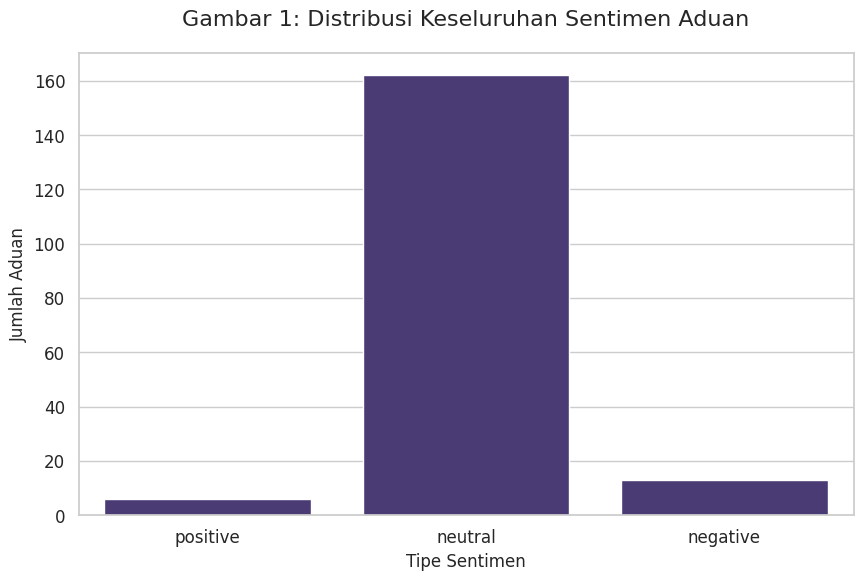

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment_label', data=df, order=['positive', 'neutral', 'negative'])
plt.title('Gambar 1: Distribusi Keseluruhan Sentimen Aduan', fontsize=16, pad=20)
plt.xlabel('Tipe Sentimen', fontsize=12)
plt.ylabel('Jumlah Aduan', fontsize=12)
plt.show()

/tmp/ipython-input-3160086580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='topic', data=top_neutral_chart, palette='plasma')


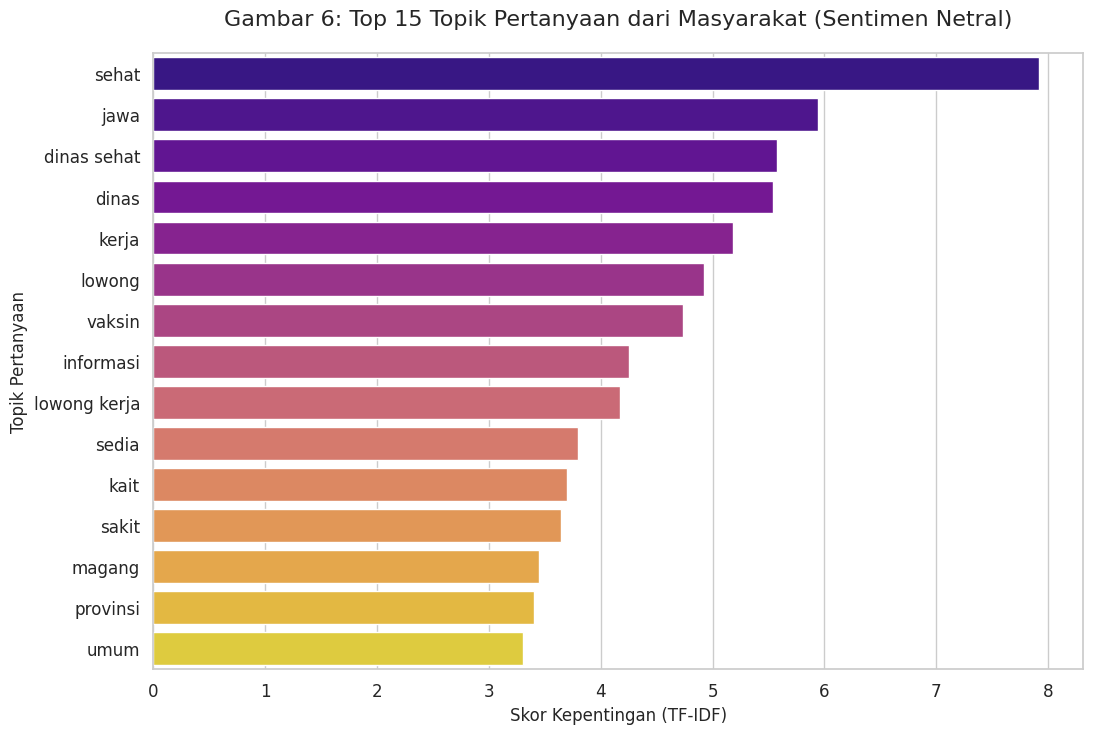

In [ ]:
# Visualisasi dengan Diagram Batang
top_n_neutral = 15
top_neutral_chart = top_neutral_topics.head(top_n_neutral)

plt.figure(figsize=(12, 8))
sns.barplot(x='score', y='topic', data=top_neutral_chart, palette='plasma')
plt.title(f'Gambar 6: Top {top_n_neutral} Topik Pertanyaan dari Masyarakat (Sentimen Netral)', fontsize=16, pad=20)
plt.xlabel('Skor Kepentingan (TF-IDF)', fontsize=12)
plt.ylabel('Topik Pertanyaan', fontsize=12)
plt.show()

/tmp/ipython-input-959991278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='topic', data=top_topics_chart, palette='mako')


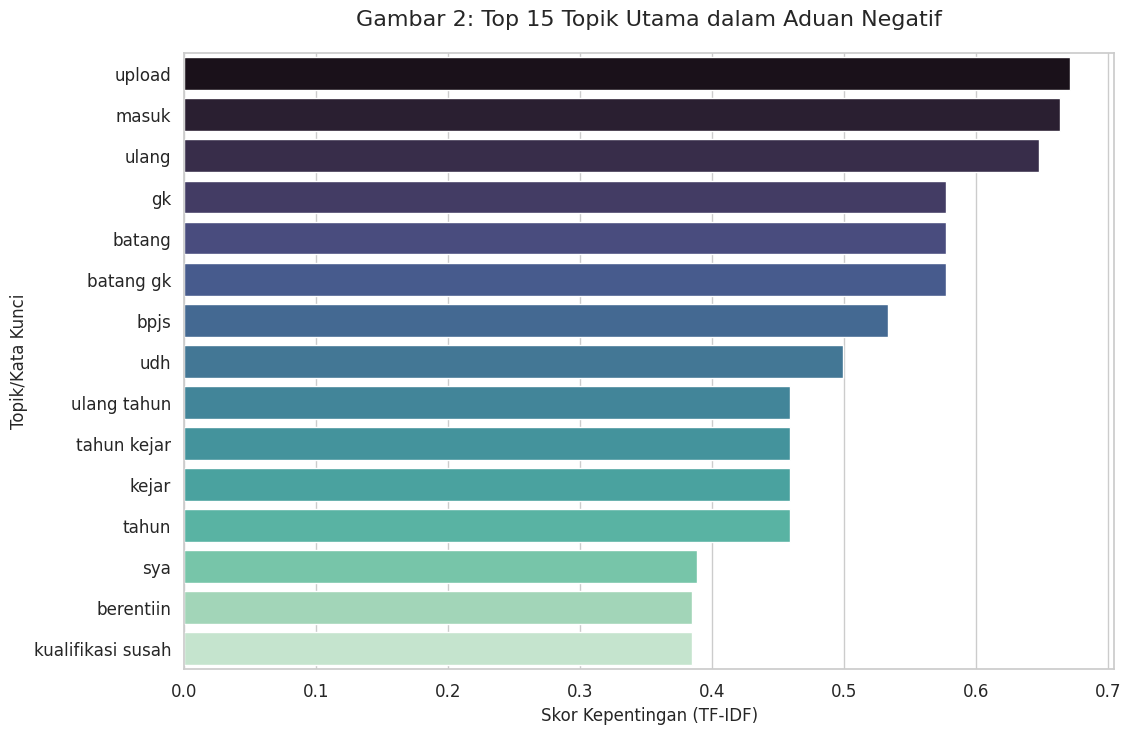

In [ ]:
# Mengambil top 15 topik dari DataFrame top_topics
top_n = 15
top_topics_chart = top_topics.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x='score', y='topic', data=top_topics_chart, palette='mako')
plt.title(f'Gambar 2: Top {top_n} Topik Utama dalam Aduan Negatif', fontsize=16, pad=20)
plt.xlabel('Skor Kepentingan (TF-IDF)', fontsize=12)
plt.ylabel('Topik/Kata Kunci', fontsize=12)
plt.show()

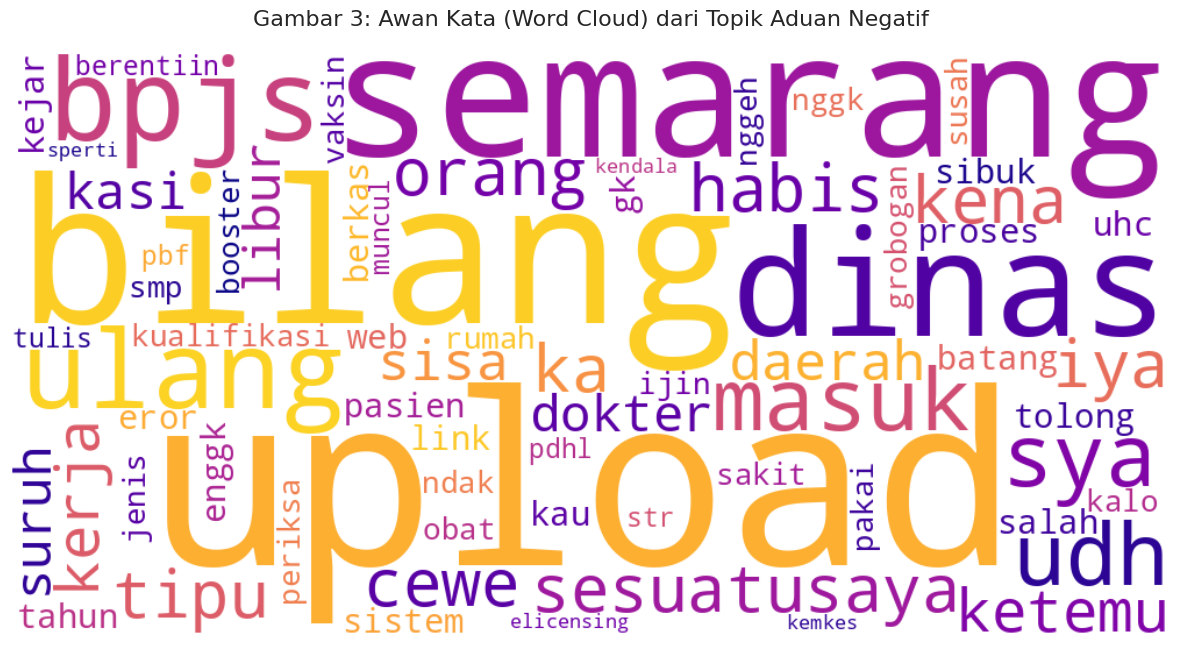

In [ ]:
# Menggabungkan semua teks negatif yang sudah di-stem menjadi satu string besar
all_negative_text = ' '.join(df_negative['stemmed_text'].dropna())

# Membuat objek WordCloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='plasma',
    max_words=100,
    contour_width=1,
    contour_color='steelblue'
)

# Menghasilkan word cloud dari teks
wordcloud.generate(all_negative_text)

# Menampilkan word cloud menggunakan matplotlib
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Gambar 3: Awan Kata (Word Cloud) dari Topik Aduan Negatif', fontsize=16, pad=20)
plt.axis('off')
plt.show()

/tmp/ipython-input-4179742947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_time_per_category.values, y=avg_time_per_category.index, palette='rocket')


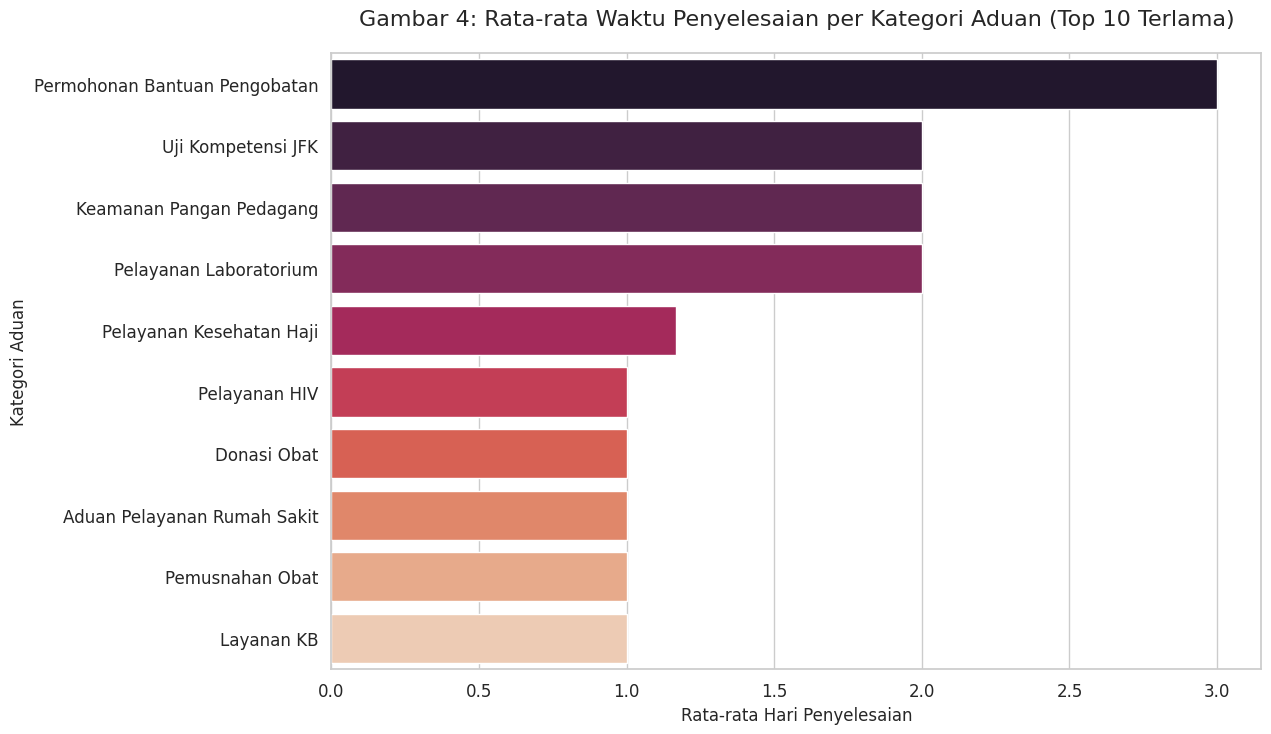

In [ ]:
# Menghitung rata-rata jangka waktu penyelesaian untuk setiap kategori aduan
avg_time_per_category = df.groupby('kategori_aduan')['jangka_waktu'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_time_per_category.values, y=avg_time_per_category.index, palette='rocket')
plt.title('Gambar 4: Rata-rata Waktu Penyelesaian per Kategori Aduan (Top 10 Terlama)', fontsize=16, pad=20)
plt.xlabel('Rata-rata Hari Penyelesaian', fontsize=12)
plt.ylabel('Kategori Aduan', fontsize=12)
plt.show()

/tmp/ipython-input-2611128826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='sumber_aduan', data=df, order = df['sumber_aduan'].value_counts().index, palette='cubehelix')


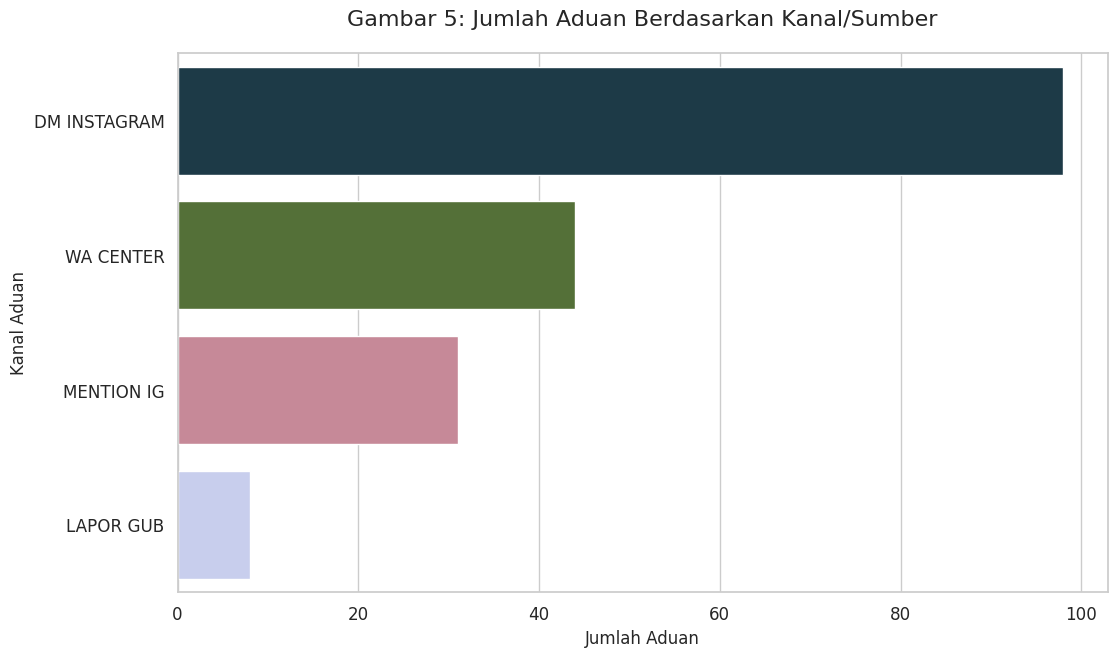

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(y='sumber_aduan', data=df, order = df['sumber_aduan'].value_counts().index, palette='cubehelix')
plt.title('Gambar 5: Jumlah Aduan Berdasarkan Kanal/Sumber', fontsize=16, pad=20)
plt.xlabel('Jumlah Aduan', fontsize=12)
plt.ylabel('Kanal Aduan', fontsize=12)
plt.show()

### Ekspor Hasil Analisis

In [ ]:
# 1. Pilih kolom
kolom_ekspor = [
    'tanggal',
    'sumber_aduan',
    'kategori_aduan',
    'teks_aduan',
    'cleaned_text',
    'stemmed_text',
    'sentiment_label',
    'sentiment_score',
    'status_penyelesaian',
    'jangka_waktu'
]

# 2. Membuat DataFrame baru
df_hasil_akhir = df[kolom_ekspor].copy()

# 3. Menentukan nama file output
nama_file_output = 'Hasil_Analisis_Aduan_Dinkes.xlsx'

# 4. Mengekspor DataFrame ke file Excel
df_hasil_akhir.to_excel(nama_file_output, index=False, engine='openpyxl')

# 5. Langsung mengunduh file ke komputer
try:
    from google.colab import files
    files.download(nama_file_output)
    print(f"File '{nama_file_output}' sedang diunduh ke komputer...")
except Exception as e:
    print(f"Gagal mengunduh otomatis, tapi file sudah tersimpan di Colab. Error: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File 'Hasil_Analisis_Aduan_Dinkes.xlsx' sedang diunduh ke komputer...
